In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [2]:
df = pd.read_csv("Assignment-A5-Social_Network_Ads.csv")

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [3]:
print(df.columns)

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [4]:
# Convert Gender to numeric (safe mapping)
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Check if any null values created (important step)
print(df.isnull().sum())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [6]:
X = df[['Gender', 'Age', 'EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [7]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)  # fit + transform
X_test = sc.transform(X_test)        # only transform

In [8]:
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nEvaluation Metrics:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Confusion Matrix:
 [[61  2]
 [10 27]]

Evaluation Metrics:
True Positives (TP): 27
False Positives (FP): 2
True Negatives (TN): 61
False Negatives (FN): 10
Accuracy: 0.88
Error Rate: 0.12
Precision: 0.93
Recall: 0.73


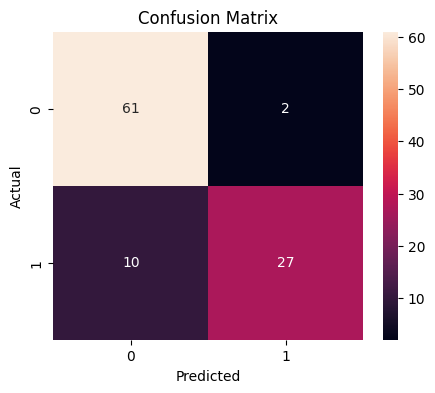

In [10]:
plt.figure(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()